1. Dataset Overview
Train: 25000,  Test: 25000
Positive/Negative: 12500/12500
First review (int): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]...
Length: 218,  Label: 1


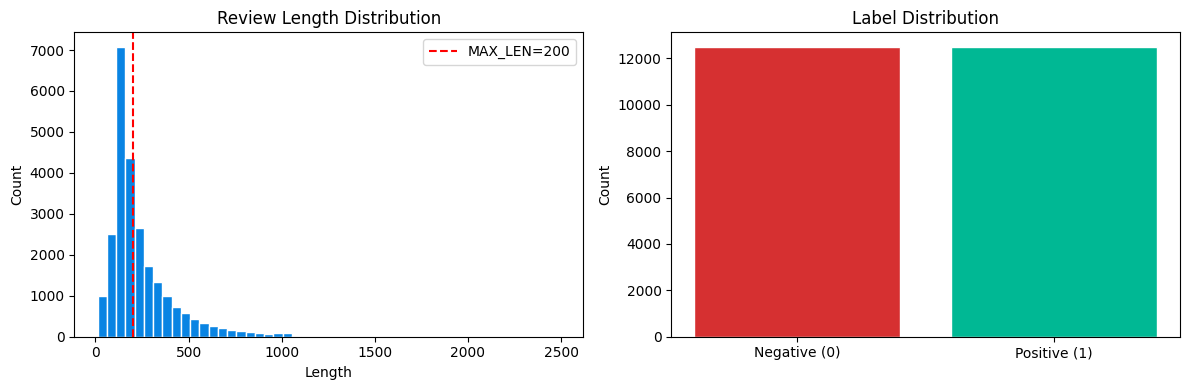


Mean: 239, Median: 178, Max: 2494
Coverage (≤200): 57.3%

2. Tokenization — Word <-> Integer Mapping

[Review #0 Decoded]
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the...

Integers: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65]
Words:    ['<START>', 'this', 'film', 'was', 'just', 'brilliant', 'casting', 'location', 'scenery', 'story']

3. Word Frequency — Top 20

Top 10:
   1. the          336,148
   2. and          164,097
   3. a            163,040
   4. of           145,847
   5. to           135,708
   6. is           107,313
   7. br           101,871
   8. in           93,934
   9. it           79,058
  10. i            77,142


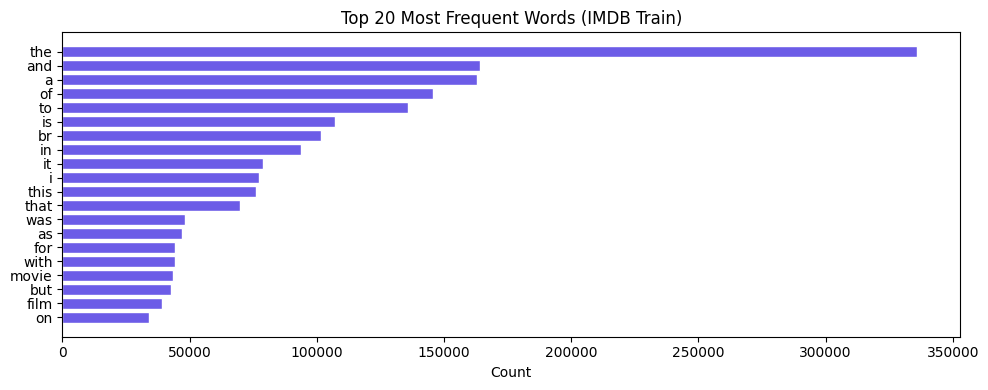

In [3]:
# ==============================
# Week 6 : IMDB Data Exploration
# Tokenization, Word Frequency, Padding
# ==============================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 10000
MAX_LEN = 200

# ==============================
# 1. Load & Explore
# ==============================
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print("=" * 50)
print("1. Dataset Overview")
print("=" * 50)
print(f"Train: {len(X_train)},  Test: {len(X_test)}")
print(f"Positive/Negative: {sum(y_train)}/{len(y_train)-sum(y_train)}")
print(f"First review (int): {X_train[0][:20]}...")
print(f"Length: {len(X_train[0])},  Label: {y_train[0]}")

lengths = [len(x) for x in X_train]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(lengths, bins=50, color='#0984e3', edgecolor='white')
ax1.axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
ax1.set(title='Review Length Distribution', xlabel='Length', ylabel='Count'); ax1.legend()
ax2.bar(['Negative (0)', 'Positive (1)'], [len(y_train)-sum(y_train), sum(y_train)],
        color=['#d63031','#00b894'], edgecolor='white')
ax2.set(title='Label Distribution', ylabel='Count')
plt.tight_layout(); plt.show()

print(f"\nMean: {np.mean(lengths):.0f}, Median: {np.median(lengths):.0f}, Max: {max(lengths)}")
print(f"Coverage (≤{MAX_LEN}): {sum(1 for l in lengths if l<=MAX_LEN)/len(lengths)*100:.1f}%")

# ==============================
# 2. Tokenization
# ==============================
print("\n" + "=" * 50)
print("2. Tokenization — Word <-> Integer Mapping")
print("=" * 50)

word_index = imdb.get_word_index()
index_to_word = {v+3: k for k, v in word_index.items()}
index_to_word.update({0:'<PAD>', 1:'<START>', 2:'<UNK>', 3:'<UNUSED>'})

decoded = ' '.join(index_to_word.get(i, '?') for i in X_train[0])
print(f"\n[Review #0 Decoded]\n{decoded[:300]}...\n")
print(f"Integers: {X_train[0][:10]}")
print(f"Words:    {[index_to_word.get(i,'?') for i in X_train[0][:10]]}")

# ==============================
# 3. Word Frequency — Top 20
# ==============================
print("\n" + "=" * 50)
print("3. Word Frequency — Top 20")
print("=" * 50)

word_counts = {}
for seq in X_train:
    for idx in seq:
        if idx >= 3:
            word_counts[idx] = word_counts.get(idx, 0) + 1

sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)
top20_words = [index_to_word.get(idx, '?') for idx, _ in sorted_words[:20]]
top20_counts = [cnt for _, cnt in sorted_words[:20]]

print("\nTop 10:")
for i, (w, c) in enumerate(zip(top20_words[:10], top20_counts[:10])):
    print(f"  {i+1:2d}. {w:12s} {c:,}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(top20_words[::-1], top20_counts[::-1], color='#6c5ce7', edgecolor='white')
ax.set(title='Top 20 Most Frequent Words (IMDB Train)', xlabel='Count')
plt.tight_layout(); plt.show()


4. Padding — pad_sequences

Before padding:
  Type: list of lists (variable length)
  Example lengths: [218, 189, 141, 550, 147]

After padding:
  X_train: (25000, 200)
  X_test:  (25000, 200)
  Sample (first 15): [  5  25 100  43 838 112  50 670   2   9  35 480 284   5 150]


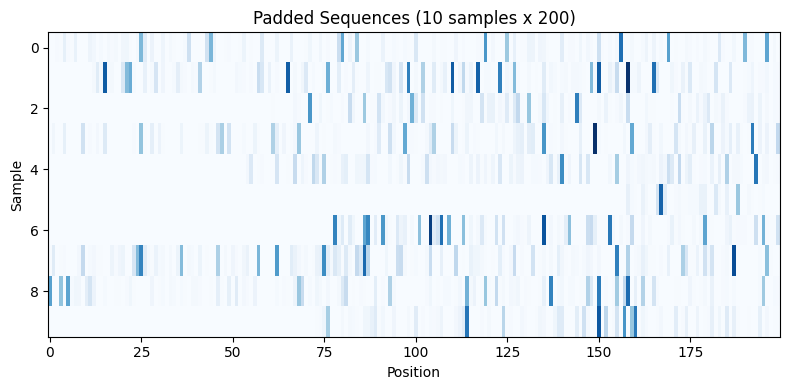

In [2]:
# ==============================
# 4. Padding
# ==============================
print("\n" + "=" * 50)
print("4. Padding — pad_sequences")
print("=" * 50)

print(f"\nBefore padding:")
print(f"  Type: list of lists (variable length)")
print(f"  Example lengths: {[len(X_train[i]) for i in range(5)]}")

X_train_pad = pad_sequences(X_train, maxlen=MAX_LEN)
X_test_pad = pad_sequences(X_test, maxlen=MAX_LEN)

print(f"\nAfter padding:")
print(f"  X_train: {X_train_pad.shape}")
print(f"  X_test:  {X_test_pad.shape}")
print(f"  Sample (first 15): {X_train_pad[0][:15]}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.imshow(X_train_pad[:10], aspect='auto', cmap='Blues')
ax.set(title=f'Padded Sequences (10 samples x {MAX_LEN})', xlabel='Position', ylabel='Sample')
plt.tight_layout(); plt.show()